In [26]:
#Make sure R can find packages installed with Conda
.libPaths('/hb/home/jbos/.conda/envs/vcfR')
.libPaths("/hb/home/jbos/.conda/envs/vcfR/lib/R/library")

In [27]:
#Load packages
library(tidyverse)
library(cowplot)
library(grid)
library(viridis)


Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp


Loading required package: viridisLite



In [1]:
#Read in PCANGSD
angsdpca<-as.matrix(read.table('/scratch/jbos/Moz_aligned_mil/angsd_output137/angsd_acropora_pca2.cov'))

In [2]:
#Read names of BAMfiles
bamlist<-read.table('/home/jbos/Moz_reads/bam_names_grp137.txt')

In [3]:
#Little function to get sample names from BAMfiles
bamnames<-function(bam){
    a<-strsplit(bam,'files/')[[1]][2]
    b<-strsplit(a,'.s')[[1]][1]
    return(b)
    }

In [7]:
indlist<-apply(bamlist,FUN=bamnames,MARGIN=1)

In [4]:
# Eigen-decomposition
eigen1 <- eigen(angsdpca)

In [5]:
# Extract eigenvalues
eigenvalues <- eigen1$values

In [8]:
# Extract eigenvectors
eigenvectors <- eigen1$vectors
rownames(eigenvectors)<-indlist

In [9]:
# Calculate variance explained
var_explained <- eigenvalues / sum(eigenvalues)
var_explained[1:5]

[1] 0.031067997 0.012174911 0.006910732 0.006706638 0.006519983

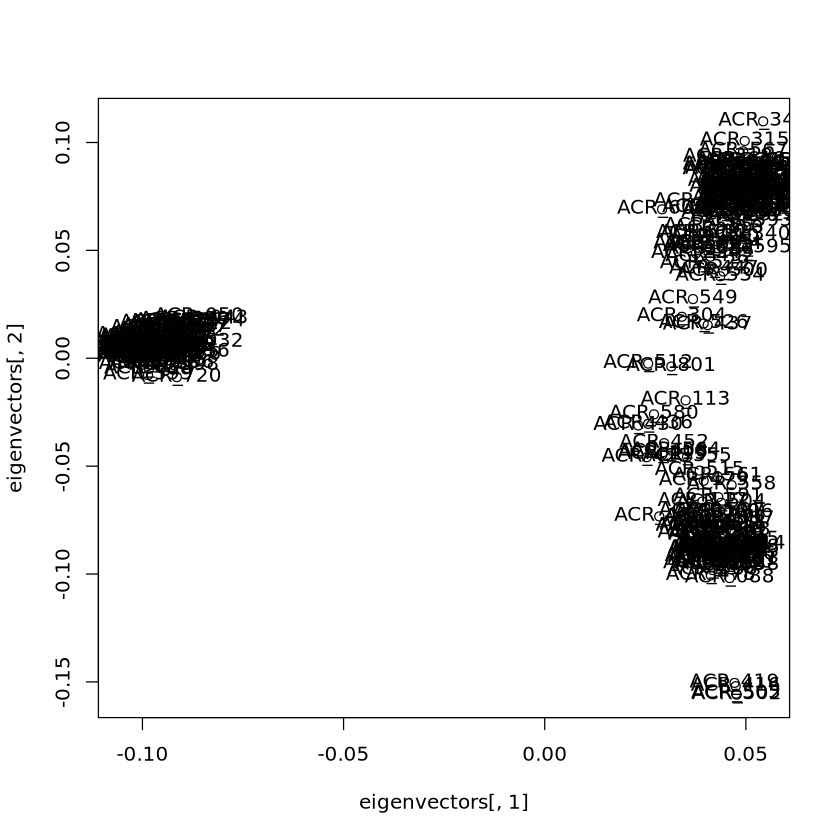

In [10]:
#Plot sample names on first two PCs
plot(eigenvectors[,1],eigenvectors[,2])
text(eigenvectors[,1],eigenvectors[,2],labels=rownames(eigenvectors))

In [31]:
#Read in metadata
metadat<-read.csv('/home/jbos/Moz_reads/Acropora_moz_metadat_certainty.csv')

In [32]:
#Little function to clean up sample names from metadata
leading_zeros<-function(num){
    if (nchar(as.character(num))<2){
        return(paste0('00',num))
        } else {
        if (nchar(as.character(num))<3){
            return(paste0('0',num))
            } else {
       return(as.character(num))
            }
        }
    }

In [33]:
#Clean up sample names from metadata
metadat$Numero_do_tubo<-sapply(metadat$Numero_do_tubo,leading_zeros)
metadat$IND<-paste("ACR_",metadat$Numero_do_tubo,sep="")

In [34]:
#Remove bad bleaching data
metadat<-metadat[,-8]

In [35]:
#Read correct bleaching data
bleaching_meta<-read.csv('/home/jbos/Moz_reads/Bleaching_Jaelyn.csv',header=TRUE)
#Add leading zero where necessary
bleaching_meta$Numero_do_tubo<-sapply(bleaching_meta$Numero_do_tubo,leading_zeros)
bleaching_meta$IND<-paste("ACR_",bleaching_meta$Numero_do_tubo,sep="")
bleaching_meta<-bleaching_meta[bleaching_meta$IND %in% indlist,]
bleaching_meta<-bleaching_meta[,c('Bleaching','Death','IND')]

In [36]:
#Combine metadata
metadat<-left_join(metadat,bleaching_meta)
eg2<-as.data.frame(eigenvectors)
eg2$IND<-indlist
rownames(metadat)<-metadat$IND
combined_pca<-inner_join(eg2,metadat)

Joining with `by = join_by(IND)`
Joining with `by = join_by(IND)`


In [43]:
#Remove clones
which(combined_pca$IND=='ACR_505')
which(combined_pca$IND=='ACR_419')
combined_pca_noclones<-combined_pca[-c(195,178),]

[1] 195

[1] 178

In [42]:
#Check number of rows
nrow(combined_pca_noclones)

[1] 234

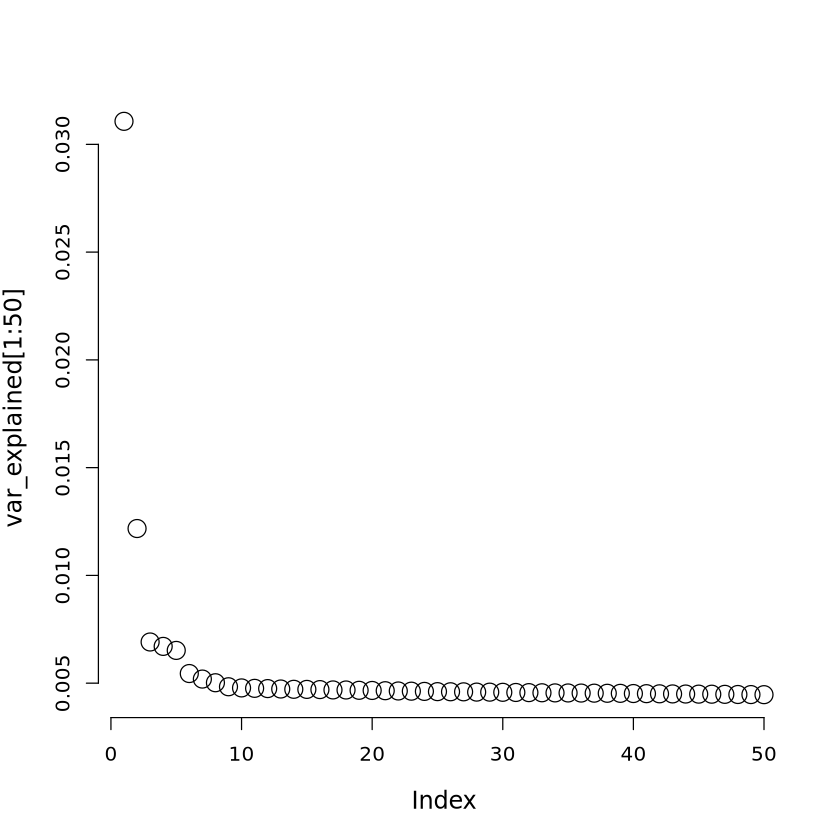

In [44]:
#Plot variance explained
plot(var_explained[1:50],axes=FALSE,cex=2,cex.lab=1.2)
axis(1)
axis(2)

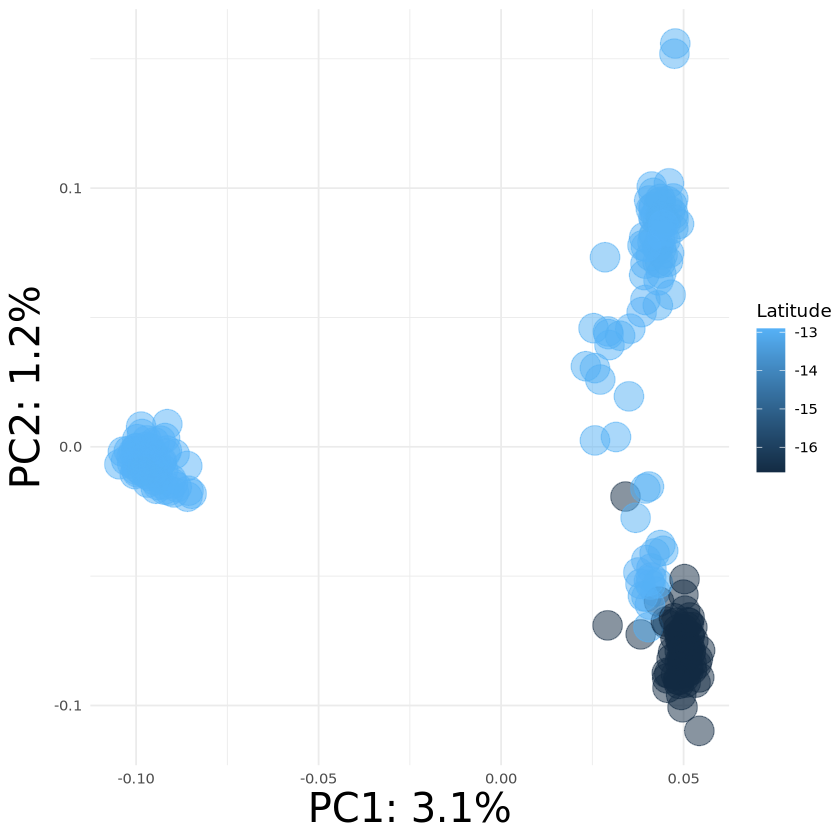

In [46]:
#Plot PCA, color by latitude. Change directon of axis2 because I like north to be on the top (am simple person)
ggplot(combined_pca_noclones, aes(x=V1, y=-1*V2,color=Latitude)) + geom_point(shape=19,size=8,alpha=0.5) +labs(x='PC1: 3.1%',y='PC2: 1.2%') + theme_minimal() +theme(axis.title = element_text(size = 24))

In [47]:
#Make sampling area into factor
combined_pca_noclones$Loc<-as.factor(combined_pca_noclones$Loc)

In [48]:
#Make dataset for bleaching only
combined24<-combined_pca_noclones[combined_pca_noclones$Ano=='2024',]
bleaching<-combined24[combined24$Bleaching %in% c('0','1'),]
bleaching<-bleaching[bleaching$Latitude>-15,]
nrow(bleaching)

[1] 131

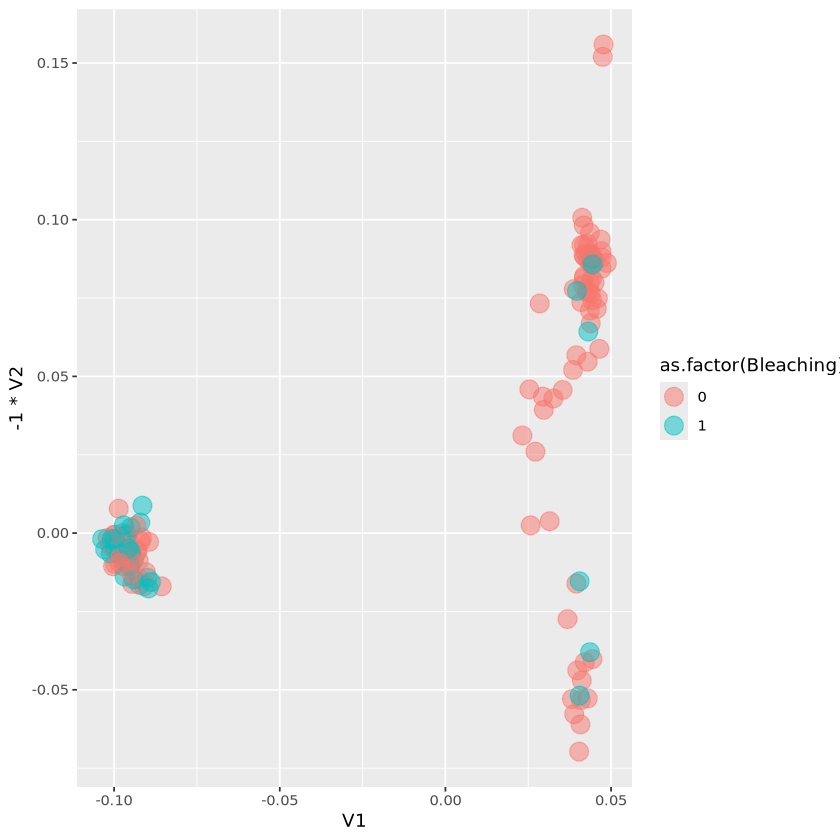

In [49]:
#Color PCA by bleaching
ggplot(bleaching, aes(x=V1, y=-1*V2,color=as.factor(Bleaching))) + geom_point(shape=19,size=5,alpha=0.5)

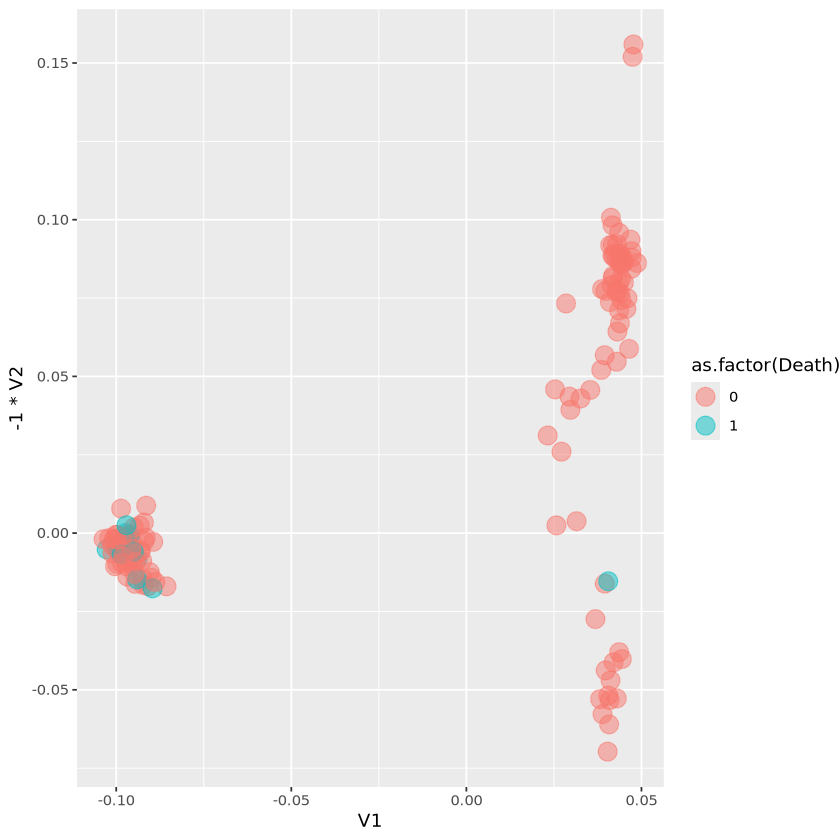

In [50]:
#Color PCA by mortality
ggplot(bleaching, aes(x=V1, y=-1*V2,color=as.factor(Death))) + geom_point(shape=19,size=5,alpha=0.5)

In [52]:
#Read in results from ADMIX
k3_admix <- as.data.frame(read.table("/scratch/jbos/Moz_aligned_mil/angsd_output137/angsd_acropora_admix2.admix.3.Q"))
k3_admix$IND<-indlist
colnames(k3_admix)<-c('DA_South','DB','DA_North','IND')

In [53]:
max_frac<-function(admix_row){
    x<-names(admix_row[1:3])[admix_row[1:3]==max(admix_row[1:3])]
    return(x)
    }

In [54]:
k3_admix$max_frac<-apply(k3_admix[,1:3],MARGIN=1,FUN=max)

In [55]:
for (i in 1:nrow(k3_admix)){
    k3_admix$main_frac[i]<-max_frac(k3_admix[i,])
    }

In [57]:
#Check ancestry fractions in DB
sppb_admix<-k3_admix[k3_admix$main_frac=='DB',]
median(sppb_admix$DB)
min(sppb_admix$DB)
median(sppb_admix$DA_North)
median(sppb_admix$DA_North)

[1] 0.9629899

[1] 0.8770097

[1] 0.0082098

[1] 0.0082098

In [58]:
#Check ancestry fractions in DA_north
north_admix<-k3_admix[k3_admix$main_frac=='DA_North',]
median(north_admix$DA_North)
median(north_admix$DA_South)
median(north_admix$DB)

max(north_admix$DA_South)
min(north_admix$DA_South)

[1] 0.7863631

[1] 0.1960279

[1] 0.02387875

[1] 0.4453794

[1] 1e-04

In [59]:
#Check ancestry fractions in DA_south
south_admix<-k3_admix[k3_admix$main_frac=='DA_South',]
median(south_admix$DA_North)
median(south_admix$DA_South)
min(south_admix$DA_South)
max(south_admix$DA_North)
median(south_admix$DB)

[1] 0.0578221

[1] 0.9240264

[1] 0.4873582

[1] 0.377905

[1] 0.0152503

In [60]:
combined_pca2<-left_join(combined_pca_noclones,k3_admix)

Joining with `by = join_by(IND)`


In [61]:
unique(combined_pca2$Loc)

[1] V    T    W    CP   CR        <NA>
Levels:  CP CR T V W

In [62]:
table(combined_pca2[combined_pca2$Latitude<(-15),]$main_frac)


DA_South 
      68 

In [63]:
table(combined_pca2[combined_pca2$Loc=='V',]$main_frac)
table(combined_pca2[combined_pca2$Loc=='T',]$main_frac)
table(combined_pca2[combined_pca2$Loc=='W',]$main_frac)
table(combined_pca2[combined_pca2$Loc=='',]$main_frac)
table(combined_pca2[combined_pca2$Loc=='CR',]$main_frac)
table(combined_pca2[combined_pca2$Loc=='CP',]$main_frac)


DA_North DA_South       DB 
      16        4       73 


DA_North DA_South 
       7        5 


DA_North DA_South 
      47       12 


DA_South 
       2 


DA_South 
      37 


DA_South 
      29 

In [64]:
combined_pca2[combined_pca2$Loc=='',]$IND
combined_pca2[combined_pca2$IND=='',]$IND

[1] "ACR_314" "ACR_319" NA        NA

character(0)

In [66]:
combined_metadat<-combined_pca2[,c('V1','V2','V3','IND','Numero_do_tubo','Latitude','Longitude','Profundidade_metros','Dia','Mes','Ano','Bleaching','Death','Loc','Spp','DA_South','DB','DA_North','max_frac','main_frac')]

In [67]:
write.csv(combined_metadat,'metadat_with_admix.csv')

In [73]:
#Make dataframe just for DA_south in Pemba
south_geno<-combined_pca2[combined_pca2$main_frac=='DA_South',]
south_geno<-south_geno[south_geno$Latitude>(-14),]
nrow(south_geno)
table(south_geno$Loc)[4:6]

[1] 21


 T  V  W 
 5  4 12 

In [74]:
#Make dataframe just for DA_north in Pemba
north_geno<-combined_pca2[combined_pca2$main_frac=='DA_North',]
north_geno<-north_geno[north_geno$Latitude>(-14),]
nrow(north_geno)
table(north_geno$Loc)[4:6]

[1] 72


 T  V  W 
 7 16 47 

In [75]:
#Chi squared test, north and south DA genotypes by location
chisq.test(table(south_geno$Loc)[4:6],table(north_geno$Loc)[4:6])
nrow(north_geno) + nrow(south_geno)

Warning message in chisq.test(table(south_geno$Loc)[4:6], table(north_geno$Loc)[4:6]):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  table(south_geno$Loc)[4:6] and table(north_geno$Loc)[4:6]
X-squared = 6, df = 4, p-value = 0.1991


[1] 93

In [76]:
#Bleaching by north and south genotypes
table(south_geno$Bleach)
table(north_geno$Bleach)


 0  1 
14  3 


 0  1 
51  4 

In [77]:
#Standard error function
se <- function(x) {
  sd(x) / sqrt(length(x))
}

In [78]:
#Mean and se of depth for north and south DA genotypes in Pemba
mean(south_geno$Profundidade_metros)
se(south_geno$Profundidade_metros)

mean(north_geno$Profundidade_metros)
se(north_geno$Profundidade_metros)

[1] 6.019048

[1] 0.663706

[1] 4.876389

[1] 0.3207453

In [79]:
#T test, depth for north and south genotypes in Pemba
median(south_geno$Profundidade_metros)
median(north_geno$Profundidade_metros)
t.test(south_geno$Profundidade_metros,north_geno$Profundidade_metros)

[1] 5.2

[1] 3.95


	Welch Two Sample t-test

data:  south_geno$Profundidade_metros and north_geno$Profundidade_metros
t = 1.5501, df = 29.972, p-value = 0.1316
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.3628515  2.6481690
sample estimates:
mean of x mean of y 
 6.019048  4.876389 


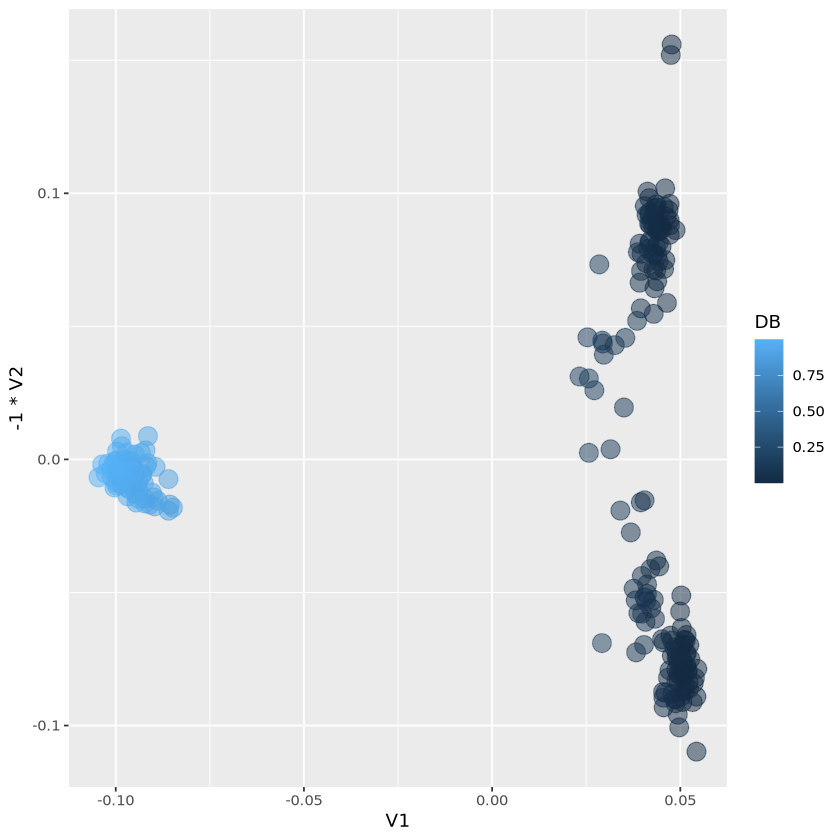

In [80]:
#Color by species DB
ggplot(combined_pca2, aes(x=V1, y=-1*V2,color=DB)) + geom_point(shape=19,size=5,alpha=0.5)

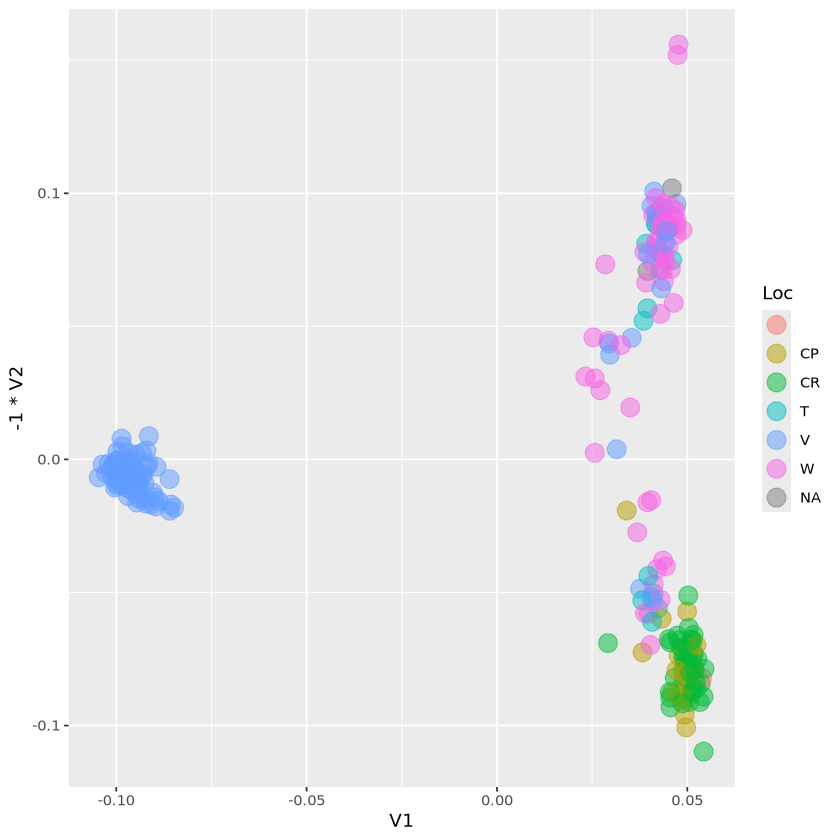

In [81]:
#Color by sampling area
ggplot(combined_pca2, aes(x=V1, y=-1*V2,color=Loc)) + geom_point(shape=19,size=5,alpha=0.5)

In [82]:
#Create long form dataframe for plotting
admix_long<-pivot_longer(k3_admix,cols=c('DB','DA_South','DA_North'),names_to='Group')
admix_long$ind_names<-factor(admix_long$IND, levels = unique(admix_long$IND)) 

In [83]:
table(admix_long$main_frac)


DA_North DA_South       DB 
     222      267      219 

In [84]:
combined_pca2$Acropora_taxon<-combined_pca2$main_frac

In [85]:
#Assign taxa to colors, for plotting
taxa_colors <- c("DA_North" = "#8FD744","DA_South" = "#35B779","DB" = "#FDE725")

In [86]:
north_rectangle <- data.frame(
  x_start = 0.01, x_end = 0.07, 
  y_start = 0, y_end = 0.18
)

In [87]:
south_rectangle <- data.frame(
  x_start = 0.01, x_end = 0.07, 
  y_start = 0, y_end = -0.12
)

In [88]:
B_rectangle <- data.frame(
  x_start = -0.11, x_end = -0.075, 
  y_start = -0.04, y_end = 0.04
)

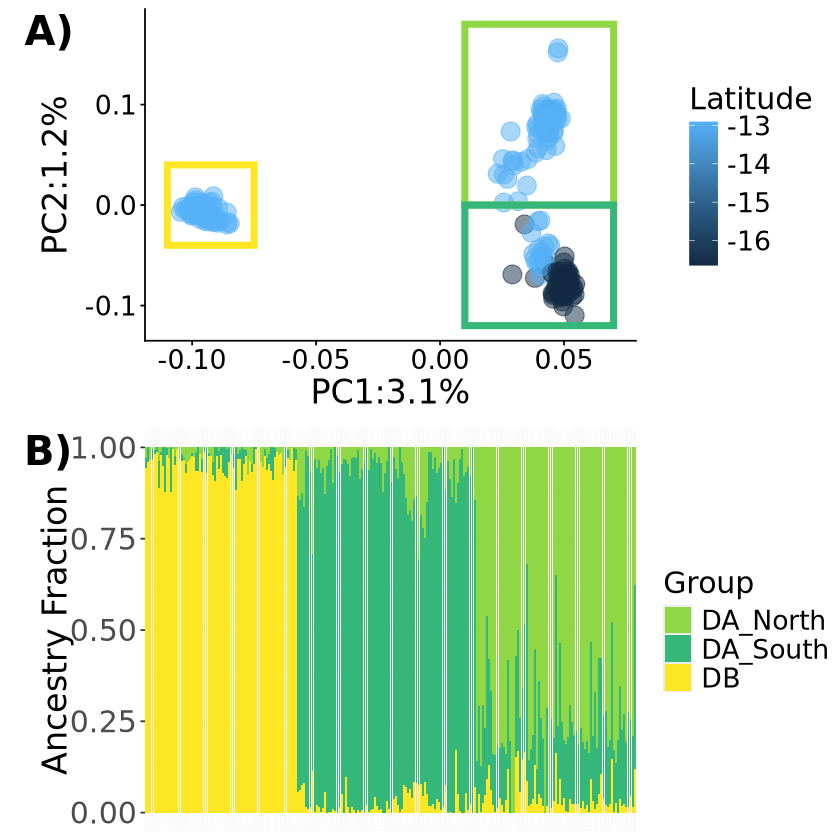

In [47]:
#Make a big unneccessarily complicated 3 panel plot
p1 <- ggplot(combined_pca2, aes(x=V1, y=V2*-1, color=Latitude)) +
  geom_point(shape=19, size=5, alpha=0.5) +
  theme_classic() +
  geom_rect(data = north_rectangle, 
            aes(xmin = x_start, xmax = x_end, ymin = y_start, ymax = y_end),  inherit.aes = FALSE,
            fill = NA, color = "#8FD744", linewidth = 2)+
  geom_rect(data = south_rectangle, 
            aes(xmin = x_start, xmax = x_end, ymin = y_start, ymax = y_end),  inherit.aes = FALSE,
            fill = NA,  color = "#35B779", linewidth = 2)+
  geom_rect(data = B_rectangle, 
            aes(xmin = x_start, xmax = x_end, ymin = y_start, ymax = y_end),  inherit.aes = FALSE,
            fill = NA,  color = "#FDE725", linewidth = 2)+
  theme(
    plot.title = element_text(size = 24),
    axis.text.x = element_text(size = 16),
    axis.text.y = element_text(size = 16),
    legend.text = element_text(size = 16),
    legend.title = element_text(size = 18),
    axis.title.x = element_text(size = 20),
    axis.title.y = element_text(size = 20))+
  labs(color = "Latitude", x = "PC1:3.1%", y = "PC2:1.2%")

plot_colors <- c("#8FD744", "#35B779","#FDE725")

adplot <- ggplot(admix_long, aes(x = ind_names, y = value, fill = Group)) +
  geom_col(position = position_fill()) +
  scale_fill_manual(values = plot_colors) +
  ylab("Ancestry Fraction") +
  theme(
    plot.title = element_text(size = 18),
    axis.title.y = element_text(size = 20),
    axis.text.x = element_blank(),
    axis.text.y = element_text(size = 18),
    axis.title.x = element_blank(),
    legend.text = element_text(size = 16),
    legend.title = element_text(size = 18),
    axis.ticks.x = element_blank(),
      labs(color = "Taxon")
  )


p1_adj <- p1 + theme(plot.margin = margin(5.5, 5.5, 5.5, 25, unit = "pt"))
adplot_adj <- adplot + theme(plot.margin = margin(5.5, 5.5, 5.5, 25, unit = "pt"))

combined <- plot_grid(
  p1_adj, adplot_adj,
  labels = c("A)", "B)"),
  label_size = 24,
  ncol = 1,
  align = "v"
)

show(combined)
# --- Save to file ---
ggsave("Adivaricata_Fig2.png", combined, width = 8, height = 10, dpi = 1200, units = "in")

In [94]:
combined_pemba<-combined_pca2[combined_pca2$Latitude>(-15),]
combined24<-combined_pemba[combined_pemba$Ano=='2024',]
bleaching<-combined_pemba[combined_pemba$Bleaching %in% c(0,1),]

In [95]:
bleaching$Spp<-'A'
bleaching$Spp[bleaching$DB>0.9]<-'B'
table(bleaching$Spp)


 A  B 
73 58 

In [96]:
bay<-bleaching[bleaching$Loc=='V',]

In [97]:
summary(glm(Bleaching ~ Latitude,bay,family='binomial'))
summary(glm(Bleaching ~ Spp,bay,family='binomial'))
summary(glm(Bleaching ~ Profundidade_metros,bay,family='binomial'))
summary(glm(Bleaching ~ Latitude+Profundidade_metros,bay,family='binomial'))
summary(glm(Bleaching ~ Latitude+Spp,bay,family='binomial'))
summary(glm(Bleaching ~ Latitude*Spp,bay,family='binomial'))


Call:
glm(formula = Bleaching ~ Latitude, family = "binomial", data = bay)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   5907.0     1456.0   4.057 4.97e-05 ***
Latitude       457.6      112.8   4.057 4.96e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 97.204  on 72  degrees of freedom
Residual deviance: 75.906  on 71  degrees of freedom
AIC: 79.906

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Bleaching ~ Spp, family = "binomial", data = bay)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)  
(Intercept)  -1.0116     0.5839  -1.733   0.0832 .
SppB          0.6633     0.6419   1.033   0.3014  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 97.204  on 72  degrees of freedom
Residual deviance: 96.070  on 71  degrees of freedom
AIC: 100.07

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Bleaching ~ Profundidade_metros, family = "binomial", 
    data = bay)

Coefficients:
                    Estimate Std. Error z value Pr(>|z|)  
(Intercept)          -2.3885     1.3629  -1.753   0.0797 .
Profundidade_metros   0.6797     0.4718   1.441   0.1497  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 97.204  on 72  degrees of freedom
Residual deviance: 94.976  on 71  degrees of freedom
AIC: 98.976

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Bleaching ~ Latitude + Profundidade_metros, family = "binomial", 
    data = bay)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)         5949.6080  1487.0081   4.001 6.31e-05 ***
Latitude             461.0752   115.2101   4.002 6.28e-05 ***
Profundidade_metros    0.6493     0.5906   1.099    0.272    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 97.204  on 72  degrees of freedom
Residual deviance: 74.651  on 70  degrees of freedom
AIC: 80.651

Number of Fisher Scoring iterations: 5



Call:
glm(formula = Bleaching ~ Latitude + Spp, family = "binomial", 
    data = bay)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) 5852.6282  1474.0254   3.971 7.17e-05 ***
Latitude     453.4287   114.1811   3.971 7.15e-05 ***
SppB           0.1635     0.7653   0.214    0.831    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 97.204  on 72  degrees of freedom
Residual deviance: 75.860  on 70  degrees of freedom
AIC: 81.86

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Bleaching ~ Latitude * Spp, family = "binomial", 
    data = bay)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)
(Intercept)      25168      69171   0.364    0.716
Latitude          1950       5358   0.364    0.716
SppB            -20267      69188  -0.293    0.770
Latitude:SppB    -1570       5359  -0.293    0.770

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 97.204  on 72  degrees of freedom
Residual deviance: 73.059  on 69  degrees of freedom
AIC: 81.059

Number of Fisher Scoring iterations: 10


In [98]:
bay_upper<-bay[bay$Latitude>(-12.907),]
bay_lower<-bay[bay$Latitude<(-12.907),]

In [99]:
table(bay[bay$Spp=='A',]$Bleach)
4/15
table(bay[bay$Spp=='B',]$Bleach)
24/(24+34)


 0  1 
11  4 

[1] 0.2666667


 0  1 
34 24 

[1] 0.4137931

In [100]:
table(bay_upper[bay_upper$Spp=='A',]$Bleach)
table(bay_upper[bay_upper$Spp=='B',]$Bleach)
table(bay_upper$Bleach)
13/18
16/21


1 
3 


 0  1 
 5 13 


 0  1 
 5 16 

[1] 0.7222222

[1] 0.7619048

In [101]:
table(bay_lower[bay_lower$Spp=='A',]$Bleach)
table(bay_lower[bay_lower$Spp=='B',]$Bleach)
table(bay_lower$Bleach)
1/12
11/(11+29)
12/52


 0  1 
11  1 


 0  1 
29 11 


 0  1 
40 12 

[1] 0.08333333

[1] 0.275

[1] 0.2307692

In [102]:
glm(Bleaching ~ Latitude,bay,family='binomial')$aic
glm(Bleaching ~ Spp,bay,family='binomial')$aic
glm(Bleaching ~ Profundidade_metros,bay,family='binomial')$aic
glm(Bleaching ~ Latitude+Profundidade_metros,bay,family='binomial')$aic
glm(Bleaching ~ Latitude+Spp,bay,family='binomial')$aic
glm(Bleaching ~ Latitude*Spp,bay,family='binomial')$aic

[1] 79.90586

[1] 100.0697

[1] 98.97557

[1] 80.65062

[1] 81.85987

[1] 81.0589

In [103]:
bay_all<-combined_pca2[combined_pca2$Loc=='V',]
bay_all$Spp<-'A'
bay_all$Spp[bay_all$DB>0.9]<-'B'
table(bay_all$Spp)
nrow(bay_all)


 A  B 
26 69 

[1] 95

In [104]:
wilcox.test(bay_all[bay_all$Spp=='B',]$Latitude,bay_all[bay_all$Spp=='A',]$Latitude)
mean(bay_all[bay_all$Spp=='B',]$Latitude,na.rm=TRUE)
mean(bay_all[bay_all$Spp=='A',]$Latitude,na.rm=TRUE)


	Wilcoxon rank sum test with continuity correction

data:  bay_all[bay_all$Spp == "B", ]$Latitude and bay_all[bay_all$Spp == "A", ]$Latitude
W = 1228.5, p-value = 0.0003882
alternative hypothesis: true location shift is not equal to 0


[1] -12.90938

[1] -12.91391

In [105]:
nrow(bay)

[1] 73

In [109]:
table(bleaching[bleaching$Loc=='T',]$Bleaching)
table(bleaching[bleaching$Loc=='W',]$Bleaching)
table(bleaching[bleaching$Loc=='V',]$Bleaching)

3/50
28/(28+45)
table(bleaching$Loc)


0 
8 


 0  1 
47  3 


 0  1 
45 28 

[1] 0.06

[1] 0.3835616


   CP CR  T  V  W 
 0  0  0  8 73 50 

In [110]:
table(bleaching[bleaching$Loc=='T',]$Death)
table(bleaching[bleaching$Loc=='W',]$Death)
table(bleaching[bleaching$Loc=='V',]$Death)

1/50
11/(28+45)


0 
8 


 0  1 
49  1 


 0  1 
62 11 

[1] 0.02

[1] 0.1506849

In [111]:
DB<-combined_pca[combined_pca2$main_frac=='DB',]
table(DB$Loc)


 V 
75 

In [112]:
DA<-combined_pca2[combined_pca2$main_frac %in% c('DA_North','DA_South'),]
table(DA$Loc)


   CP CR  T  V  W 
 2 29 37 12 20 59 

In [113]:
DB_bleaching<-DB[DB$Ano=='2024',]

In [61]:
bamlist<-function(ind){
    a<-paste0('/scratch/jbos/Moz_aligned_mil/amillepora_bamfiles/',ind)
    b<-paste0(a,'.sorted.bam')
    return(b)
    }

In [62]:
colnames(DB_bleaching)

[1] "V1"                  "V2"                  "V3"                 
  [4] "V4"                  "V5"                  "V6"                 
  [7] "V7"                  "V8"                  "V9"                 
 [10] "V10"                 "V11"                 "V12"                
 [13] "V13"                 "V14"                 "V15"                
 [16] "V16"                 "V17"                 "V18"                
 [19] "V19"                 "V20"                 "V21"                
 [22] "V22"                 "V23"                 "V24"                
 [25] "V25"                 "V26"                 "V27"                
 [28] "V28"                 "V29"                 "V30"                
 [31] "V31"                 "V32"                 "V33"                
 [34] "V34"                 "V35"                 "V36"                
 [37] "V37"                 "V38"                 "V39"                
 [40] "V40"                 "V41"                 "V42"                
 [43] "V43"                 "V44"                 "V45"                
 [46] "V46"                 "V47"                 "V48"                
 [49] "V49"                 "V50"                 "V51"                
 [52] "V52"                 "V53"                 "V54"                
 [55] "V55"                 "V56"                 "V57"                
 [58] "V58"                 "V59"                 "V60"                
 [61] "V61"                 "V62"                 "V63"                
 [64] "V64"                 "V65"                 "V66"                
 [67] "V67"                 "V68"                 "V69"                
 [70] "V70"                 "V71"                 "V72"                
 [73] "V73"                 "V74"                 "V75"                
 [76] "V76"                 "V77"                 "V78"                
 [79] "V79"                 "V80"                 "V81"                
 [82] "V82"                 "V83"                 "V84"                
 [85] "V85"                 "V86"                 "V87"                
 [88] "V88"                 "V89"                 "V90"                
 [91] "V91"                 "V92"                 "V93"                
 [94] "V94"                 "V95"                 "V96"                
 [97] "V97"                 "V98"                 "V99"                
[100] "V100"                "V101"                "V102"               
[103] "V103"                "V104"                "V105"               
[106] "V106"                "V107"                "V108"               
[109] "V109"                "V110"                "V111"               
[112] "V112"                "V113"                "V114"               
[115] "V115"                "V116"                "V117"               
[118] "V118"                "V119"                "V120"               
[121] "V121"                "V122"                "V123"               
[124] "V124"                "V125"                "V126"               
[127] "V127"                "V128"                "V129"               
[130] "V130"                "V131"                "V132"               
[133] "V133"                "V134"                "V135"               
[136] "V136"                "V137"                "V138"               
[139] "V139"                "V140"                "V141"               
[142] "V142"                "V143"                "V144"               
[145] "V145"                "V146"                "V147"               
[148] "V148"                "V149"                "V150"               
[151] "V151"                "V152"                "V153"               
[154] "V154"                "V155"                "V156"               
[157] "V157"                "V158"                "V159"               
[160] "V160"                "V161"                "V162"               
[163] "V163"                "V164"                "V165"               
[166] "V166"                "V167"        

In [63]:
nrow(DB_bleaching)
DB_inds_2024<-bamlist(DB_bleaching$IND)
write.table(DB_inds_2024,'/home/jbos/Moz_reads/bam_names_DB_2024.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

[1] 60

In [64]:
table(DB_bleaching$Bleaching==0)


FALSE  TRUE 
   24    35 

In [65]:
DB_bleaching$bleaching_resistance<-0
DB_bleaching$bleaching_resistance[DB_bleaching$Bleaching==0]<-1

In [66]:
write.table(DB_bleaching$bleaching_resistance,'/home/jbos/Moz_reads/DB_bleach.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [67]:
table(DB_bleaching$bleaching_resistance)


 0  1 
25 35 

In [68]:
DB_covariates<-as.data.frame(matrix(nrow=nrow(DB_bleaching), ncol=2))

In [175]:
#First covariate: depth
DB_covariates[,1]<-DB_bleaching$Profundidade_metros

In [176]:
#Second covariate: inner bay vs. outer bay. Latitude as proxy
DB_covariates[,2]<-DB_bleaching$Latitude

In [179]:
write.table(DB_covariates,'/home/jbos/Moz_reads/DB_covariates.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [180]:
DA_bleaching<-DA[DA$Ano=='2024',]
DA_bleaching_Wimbe<-DA_bleaching[DA_bleaching$Loc =='W',]

In [182]:
DA_bleaching_Wimbe$bleaching_resistance<-0
DA_bleaching_Wimbe$bleaching_resistance[DA_bleaching_Wimbe$Bleaching==0]<-1

In [183]:
table(DA_bleaching_Wimbe$bleaching_resistance)


 0  1 
 5 47 

In [184]:
write.table(DA_bleaching_Wimbe$bleaching_resistance,'/home/jbos/Moz_reads/DA_bleach_Wimbe.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [185]:
nrow(DA_bleaching_Wimbe)
DA_bleaching_Wimbe_inds<-bamlist(DA_bleaching_Wimbe$IND)
write.table(DA_bleaching_Wimbe_inds,'/home/jbos/Moz_reads/bam_names_DA_wimbe.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

[1] 52

In [186]:
DA_covariates<-as.data.frame(matrix(nrow=nrow(DA_bleaching_Wimbe), ncol=1))

In [187]:
#First covariate: depth
DA_covariates[,1]<-DA_bleaching_Wimbe$Profundidade_metros

In [188]:
write.table(DA_covariates,'/home/jbos/Moz_reads/DA_covariates.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [69]:
Bay_bleaching<-combined_pca2[combined_pca2$Ano=='2024',]

In [71]:
Bay_bleaching<-Bay_bleaching[Bay_bleaching$Loc =='V',]

In [72]:
Bay_bleaching$bleaching_resistance<-0
Bay_bleaching$bleaching_resistance[Bay_bleaching$Bleaching==0]<-1

In [73]:
table(Bay_bleaching$bleaching_resistance)


 0  1 
29 45 

In [194]:
write.table(Bay_bleaching$bleaching_resistance,'/home/jbos/Moz_reads/bleach_Bay.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [196]:
nrow(Bay_bleaching)
Bay_bleaching_inds<-bamlist(Bay_bleaching$IND)
write.table(Bay_bleaching_inds,'/home/jbos/Moz_reads/bam_names_bay.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

[1] 74

In [74]:
Bay_covariates<-as.data.frame(matrix(nrow=nrow(Bay_bleaching), ncol=2))

In [79]:
#First covariate: depth
Bay_covariates[,1]<-Bay_bleaching$Profundidade_metros

In [78]:
#Second covariate: inner bay vs. outer bay. Latitude as proxy
Bay_covariates[,2]<-Bay_bleaching$Latitude

In [81]:
write.table(Bay_covariates,'/home/jbos/Moz_reads/Bay_covariates.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

In [199]:
which(DA$IND=='ACR_505')
which(DA$IND=='ACR_419')

integer(0)

integer(0)

In [79]:
Grp37_noclones<-combined_pca2[-c(105,122),]

In [76]:
which(combined_pca2$IND=='ACR_505')
which(combined_pca2$IND=='ACR_419')

[1] 195

[1] 178

In [77]:
Grp137_noclones<-combined_pca2[-c(178,195),]

In [80]:
caldeira<-Grp137_noclones[Grp137_noclones$Latitude<(-15),]
pemba_broad<-Grp137_noclones[Grp137_noclones$Latitude>(-15),]
pemba_narrow<-Grp37_noclones[Grp37_noclones$Latitude>(-15),]

In [84]:
cald<-bamlist(caldeira$IND)
nrow(caldeira)
write.table(cald,'/home/jbos/Moz_reads/bam_names_caldeira.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

[1] 68

In [85]:
pb<-bamlist(pemba_broad$IND)
nrow(pemba_broad)
write.table(pb,'/home/jbos/Moz_reads/bam_names_pemba_broad.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

[1] 166

In [86]:
pn<-bamlist(pemba_narrow$IND)
nrow(pemba_narrow)
write.table(pn,'/home/jbos/Moz_reads/bam_names_pemba_narrow.txt',row.names=FALSE,col.names=FALSE,quote=FALSE)

[1] 168